<a href="https://colab.research.google.com/github/sameerkarur/Data_science/blob/main/07_IITK_AIML_Capstone/project2_sales_forecasting/lms_upload/sales_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Course 7 Capstone — Project 2: Sales Forecasting
### Fresh Analytics | Multi-Restaurant Demand Prediction

**Objective.** Forecast item demand across restaurants so operations, staffing, and inventory can be planned with greater accuracy.

**Data window.** Daily item-level sales from **2019-01-01** through **2021-12-31**, linked to item nutrition/cost metadata and restaurant (store) names.

**Approach.**
1. **Preliminary analysis** — load, profile, detect outliers, merge into an analysis-ready table  
2. **Exploratory data analysis** — seasonality, restaurant performance, item popularity, revenue vs volume  
3. **Machine learning forecasting** — Linear Regression, Random Forest, and XGBoost on calendar features; last 6 months held out; best model projects the next 365 days  

**Deliverables.** Executed notebook, plots under `outputs/`, STAR write-up, and LMS upload package.

## 0. Environment & imports

Configure paths, plotting defaults, and reproducibility. XGBoost on macOS may require `libomp` on `DYLD_LIBRARY_PATH`.

In [1]:
from __future__ import annotations

import os
import warnings
from pathlib import Path

# Helpful for XGBoost + OpenMP on Apple Silicon / Homebrew
_libomp = "/opt/homebrew/opt/libomp/lib"
if Path(_libomp).exists():
    os.environ["DYLD_LIBRARY_PATH"] = f"{_libomp}:{os.environ.get('DYLD_LIBRARY_PATH', '')}"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import xgboost as xgb

from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
})

PROJECT_ROOT = Path(".").resolve()
DATA_DIR = PROJECT_ROOT / "data"
OUT_DIR = PROJECT_ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Project root : {PROJECT_ROOT}")
print(f"Data dir     : {DATA_DIR}")
print(f"Outputs dir  : {OUT_DIR}")
print(f"pandas {pd.__version__} | numpy {np.__version__} | xgboost {xgb.__version__}")

Matplotlib is building the font cache; this may take a moment.


Project root : /Users/sameerkarur/Documents/Git/Data_science/07_IITK_AIML_Capstone/project2_sales_forecasting
Data dir     : /Users/sameerkarur/Documents/Git/Data_science/07_IITK_AIML_Capstone/project2_sales_forecasting/data
Outputs dir  : /Users/sameerkarur/Documents/Git/Data_science/07_IITK_AIML_Capstone/project2_sales_forecasting/outputs
pandas 3.0.5 | numpy 2.5.2 | xgboost 3.4.1


---
## 1. Preliminary analysis

### 1a. Import the datasets

Three source files (note the intentional typo in the restaurant filename from the source dump: `resturants.csv`):

| File | Role |
|------|------|
| `sales.csv` | Daily item sales: date, item_id, price, item_count |
| `items.csv` | Item catalog: id, store_id, name, kcal, cost |
| `resturants.csv` | Store directory: id, name |

In [2]:
sales_raw = pd.read_csv(DATA_DIR / "sales.csv", parse_dates=["date"])
items_raw = pd.read_csv(DATA_DIR / "items.csv")
restaurants_raw = pd.read_csv(DATA_DIR / "resturants.csv")  # filename typo retained

print("=== sales.csv ===")
display(sales_raw.head())
print("\n=== items.csv ===")
display(items_raw.head())
print("\n=== resturants.csv ===")
display(restaurants_raw)

=== sales.csv ===


,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.0
1,2019-01-01,4,26.42,22.0
2,2019-01-01,12,4.87,7.0
3,2019-01-01,13,4.18,12.0
4,2019-01-01,16,3.21,136.0



=== items.csv ===


,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07



=== resturants.csv ===


,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe
5,6,Surfs Up


### 1b. Shape, structure, and outliers

We inspect dimensions, dtypes, missingness, uniqueness, and distributional outliers on `item_count` and `price`.

In [3]:
def profile(df: pd.DataFrame, name: str) -> None:
    print(f"\n{'=' * 60}\n{name}\n{'=' * 60}")
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print("\nDtypes:")
    print(df.dtypes)
    print("\nMissing values:")
    print(df.isna().sum())
    print(f"\nDuplicate rows: {df.duplicated().sum():,}")
    display(df.describe(include="all").T)


profile(sales_raw, "sales")
profile(items_raw, "items")
profile(restaurants_raw, "restaurants")

print(
    f"\nSales date range: {sales_raw['date'].min().date()} → {sales_raw['date'].max().date()}"
)
print(f"Unique item_ids in sales : {sales_raw['item_id'].nunique()}")
print(f"Unique items in catalog  : {items_raw['id'].nunique()}")
print(f"Unique stores            : {restaurants_raw['id'].nunique()}")
print(
    f"Zero-count sales rows    : {(sales_raw['item_count'] == 0).sum():,} "
    f"({(sales_raw['item_count'] == 0).mean():.1%}) — sparse panel of all item×day combos"
)


sales
Shape: 109,600 rows × 4 columns

Dtypes:
date          datetime64[us]
item_id                int64
price                float64
item_count           float64
dtype: object

Missing values:
date          0
item_id       0
price         0
item_count    0
dtype: int64

Duplicate rows: 0


,count,mean,min,25%,50%,75%,max,std
date,109600,2020-07-01 12:00:00,2019-01-01 00:00:00,2019-10-01 18:00:00,2020-07-01 12:00:00,2021-04-01 06:00:00,2021-12-31 00:00:00,NaN
item_id,109600.0,50.5,1.0,25.75,50.5,75.25,100.0,28.866202
price,109600.0,11.7637,1.39,5.28,7.625,18.79,53.98,8.946225
item_count,109600.0,6.339297,0.0,0.0,0.0,0.0,570.0,30.003728



items
Shape: 100 rows × 5 columns

Dtypes:
id            int64
store_id      int64
name            str
kcal          int64
cost        float64
dtype: object

Missing values:
id          0
store_id    0
name        0
kcal        0
cost        0
dtype: int64

Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,100.0,NaN,NaN,NaN,50.5,29.011492,1.0,25.75,50.5,75.25,100.0
store_id,100.0,NaN,NaN,NaN,3.52,1.708446,1.0,2.0,4.0,5.0,6.0
name,100,94,Milky Cake,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kcal,100.0,NaN,NaN,NaN,536.73,202.212852,78.0,406.25,572.5,638.25,1023.0
cost,100.0,NaN,NaN,NaN,11.7637,8.991254,1.39,5.28,7.625,18.79,53.98



restaurants
Shape: 6 rows × 2 columns

Dtypes:
id      int64
name      str
dtype: object

Missing values:
id      0
name    0
dtype: int64

Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,6.0,NaN,NaN,NaN,3.5,1.870829,1.0,2.25,3.5,4.75,6.0
name,6,6,Bob's Diner,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Sales date range: 2019-01-01 → 2021-12-31
Unique item_ids in sales : 100
Unique items in catalog  : 100
Unique stores            : 6
Zero-count sales rows    : 86,116 (78.6%) — sparse panel of all item×day combos


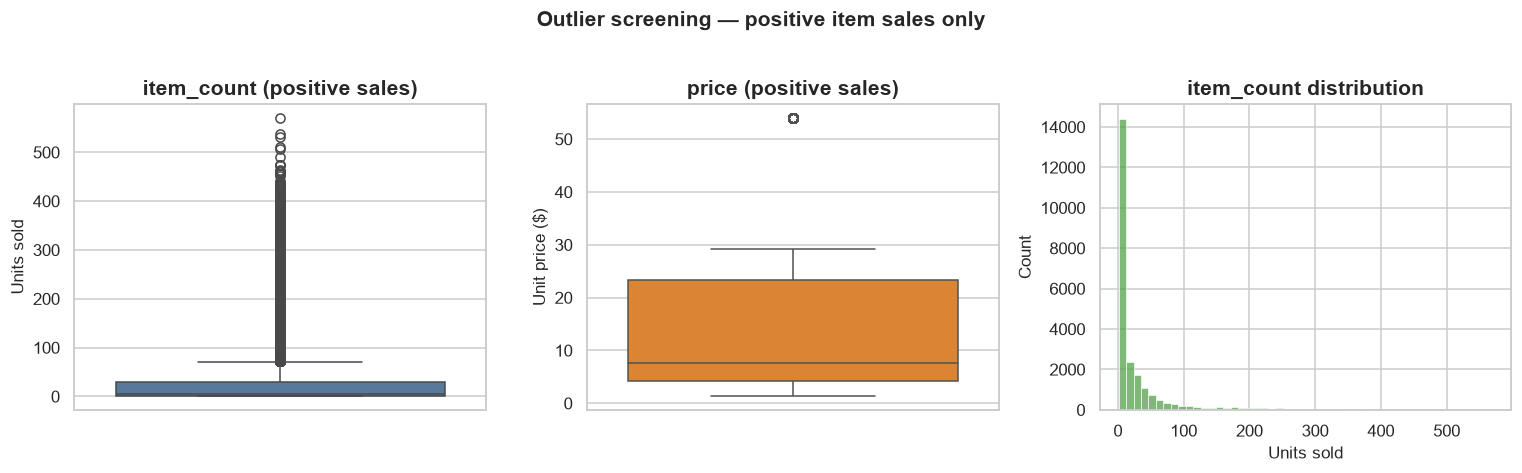

item_count IQR: Q1=1.0, Q3=29.0, IQR=28.0
Tukey fences  : [-41.0, 71.0]
Outliers among positive sales: 2,595 / 23,484 (11.1%)
Interpretation: right-skewed demand with occasional high-volume days is expected in restaurant data; we retain outliers for forecasting (they carry signal).


In [4]:
def iqr_bounds(s: pd.Series, k: float = 1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr, q1, q3, iqr


# Focus outlier review on positive sales (zeros dominate the panel)
pos = sales_raw.loc[sales_raw["item_count"] > 0].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

sns.boxplot(y=pos["item_count"], ax=axes[0], color="#4C78A8")
axes[0].set_title("item_count (positive sales)")
axes[0].set_ylabel("Units sold")

sns.boxplot(y=pos["price"], ax=axes[1], color="#F58518")
axes[1].set_title("price (positive sales)")
axes[1].set_ylabel("Unit price ($)")

sns.histplot(pos["item_count"], bins=50, ax=axes[2], color="#54A24B", edgecolor=None)
axes[2].set_title("item_count distribution")
axes[2].set_xlabel("Units sold")

plt.suptitle("Outlier screening — positive item sales only", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "01_outliers_item_count_price.png")
plt.show()

lo, hi, q1, q3, iqr = iqr_bounds(pos["item_count"])
n_out = ((pos["item_count"] < lo) | (pos["item_count"] > hi)).sum()
print(f"item_count IQR: Q1={q1:.1f}, Q3={q3:.1f}, IQR={iqr:.1f}")
print(f"Tukey fences  : [{lo:.1f}, {hi:.1f}]")
print(
    f"Outliers among positive sales: {n_out:,} / {len(pos):,} "
    f"({n_out / len(pos):.1%})"
)
print(
    "Interpretation: right-skewed demand with occasional high-volume days is expected "
    "in restaurant data; we retain outliers for forecasting (they carry signal)."
)

### 1c. Merge into a single analysis dataset

Join path: `sales.item_id → items.id` and `items.store_id → restaurants.id`.

**Resulting columns:** date, item id, price, item count, item names, kcal, store id, store name (+ derived `revenue` and `cost` for margin-aware EDA).

In [5]:
df = (
    sales_raw.merge(items_raw, left_on="item_id", right_on="id", how="left", suffixes=("", "_item"))
    .drop(columns=["id"])
    .merge(
        restaurants_raw.rename(columns={"id": "store_id", "name": "store_name"}),
        on="store_id",
        how="left",
    )
    .rename(columns={"name": "item_name"})
)

# Ensure required column set and friendly order
df["revenue"] = df["price"] * df["item_count"]
df = df[
    [
        "date",
        "item_id",
        "item_name",
        "price",
        "item_count",
        "kcal",
        "cost",
        "store_id",
        "store_name",
        "revenue",
    ]
].sort_values(["date", "store_id", "item_id"]).reset_index(drop=True)

assert df[["item_name", "store_name", "kcal"]].isna().sum().sum() == 0, "Unexpected nulls after merge"

print(f"Merged shape: {df.shape[0]:,} × {df.shape[1]}")
print(f"Date span   : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Stores      : {df['store_name'].nunique()} | Items: {df['item_id'].nunique()}")
display(df.head(10))
display(df.sample(5, random_state=RANDOM_STATE))

Merged shape: 109,600 × 10
Date span   : 2019-01-01 → 2021-12-31
Stores      : 6 | Items: 100


,date,item_id,item_name,price,item_count,kcal,cost,store_id,store_name,revenue
0,2019-01-01,3,Sweet Fruity Cake,29.22,2.0,931,29.22,1,Bob's Diner,58.44
1,2019-01-01,4,Amazing Steak Dinner with Rolls,26.42,22.0,763,26.42,1,Bob's Diner,581.24
2,2019-01-01,9,Orange Juice,3.91,0.0,135,3.91,1,Bob's Diner,0.00
3,2019-01-01,12,Fantastic Sweet Cola,4.87,7.0,478,4.87,1,Bob's Diner,34.09
4,2019-01-01,13,Sweet Frozen Soft Drink,4.18,12.0,490,4.18,1,Bob's Diner,50.16
5,2019-01-01,16,Frozen Milky Smoothy,3.21,136.0,284,3.21,1,Bob's Diner,436.56
6,2019-01-01,18,Mutton Lunch Plate,18.82,0.0,566,18.82,1,Bob's Diner,0.00
7,2019-01-01,19,Strawberry Smoothy,2.89,108.0,145,2.89,1,Bob's Diner,312.12
8,2019-01-01,21,Amazing Fish with Vegetables Meal,23.23,13.0,269,23.23,1,Bob's Diner,301.99
9,2019-01-01,23,Awesome Sweet Lamb Cake,10.86,10.0,671,10.86,1,Bob's Diner,108.60


,date,item_id,item_name,price,item_count,kcal,cost,store_id,store_name,revenue
44479,2020-03-20,60,Original Pork Meal,15.69,0.0,411,15.69,5,Corner Cafe,0.00
70455,2020-12-05,72,Original Milky Cake,6.53,0.0,602,6.53,4,Fou Cher,0.00
56897,2020-07-22,88,Oysters Rockefeller,16.06,2.0,204,16.06,6,Surfs Up,32.12
72117,2020-12-22,56,Sea Bass with Vegetables Dinner,28.75,7.0,613,28.75,1,Bob's Diner,201.25
54651,2020-06-30,51,Amazing Lamb Dinner,17.55,0.0,591,17.55,4,Fou Cher,0.00


---
## 2. Exploratory data analysis

Unless noted, **sales volume** means sum of `item_count` and **sales value** means sum of `revenue` (`price × item_count`).

### 2a. Overall sales pattern

Daily totals reveal level, seasonality, and any structural shifts across 2019–2021.

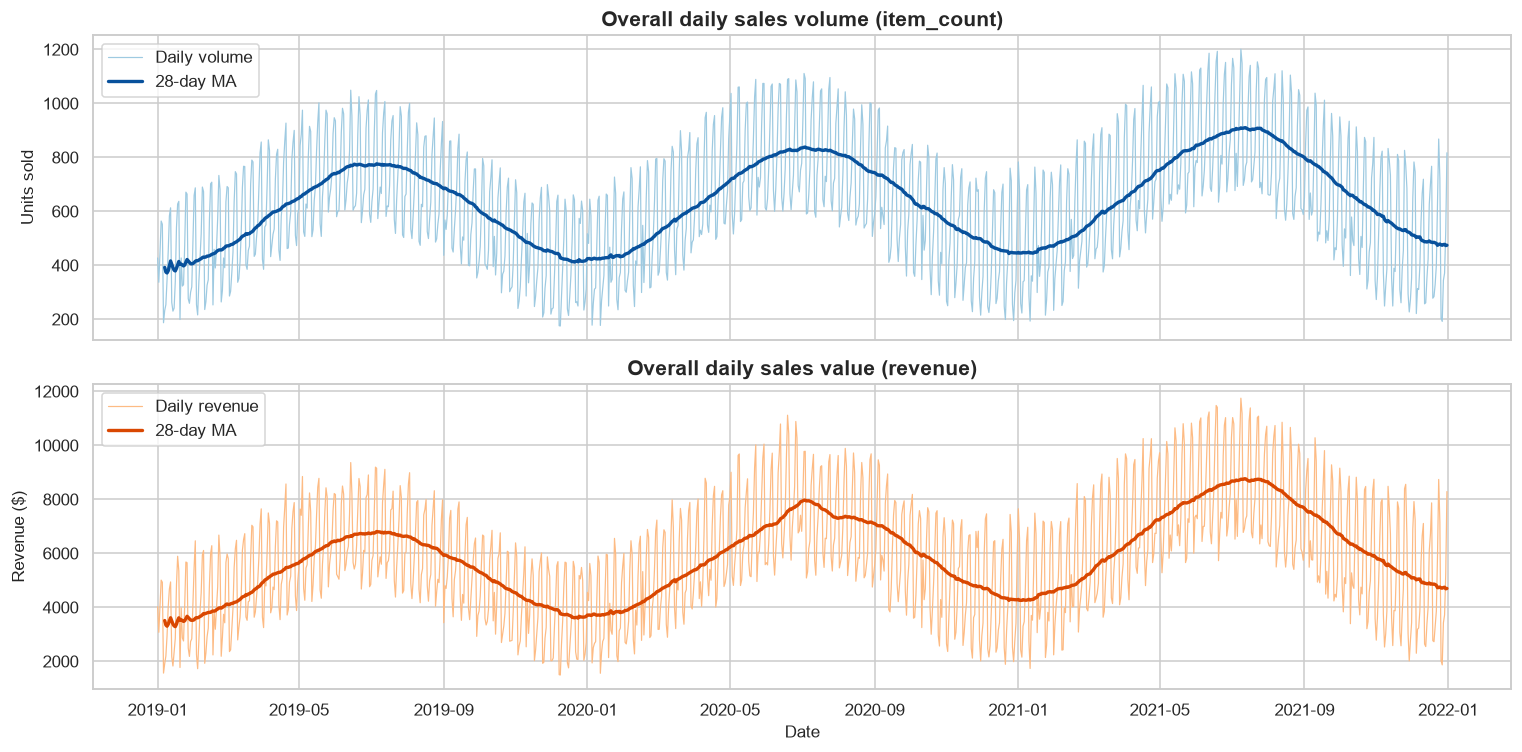

Mean daily volume : 633.9 units | Mean daily revenue: $5,843
Peak volume day   : 2021-07-09 (1,201 units)
Insight: volume and revenue move together with clear weekly oscillation and mild multi-year growth — calendar features should be highly informative.


In [6]:
daily = (
    df.groupby("date", as_index=False)
    .agg(item_count=("item_count", "sum"), revenue=("revenue", "sum"))
    .sort_values("date")
)
daily["rolling_28"] = daily["item_count"].rolling(28, min_periods=7).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(daily["date"], daily["item_count"], color="#9ECAE1", lw=0.8, label="Daily volume")
axes[0].plot(daily["date"], daily["rolling_28"], color="#08519C", lw=2.2, label="28-day MA")
axes[0].set_ylabel("Units sold")
axes[0].set_title("Overall daily sales volume (item_count)")
axes[0].legend(loc="upper left")

axes[1].plot(daily["date"], daily["revenue"], color="#FDBB84", lw=0.8, label="Daily revenue")
axes[1].plot(
    daily["date"],
    daily["revenue"].rolling(28, min_periods=7).mean(),
    color="#D94701",
    lw=2.2,
    label="28-day MA",
)
axes[1].set_ylabel("Revenue ($)")
axes[1].set_xlabel("Date")
axes[1].set_title("Overall daily sales value (revenue)")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.savefig(OUT_DIR / "02a_overall_sales_pattern.png")
plt.show()

print(
    f"Mean daily volume : {daily['item_count'].mean():,.1f} units | "
    f"Mean daily revenue: ${daily['revenue'].mean():,.0f}"
)
print(
    f"Peak volume day   : {daily.loc[daily['item_count'].idxmax(), 'date'].date()} "
    f"({daily['item_count'].max():,.0f} units)"
)
print(
    "Insight: volume and revenue move together with clear weekly oscillation and "
    "mild multi-year growth — calendar features should be highly informative."
)

### 2b. Sales by day of week

Weekend vs weekday effects drive staffing and prep decisions.

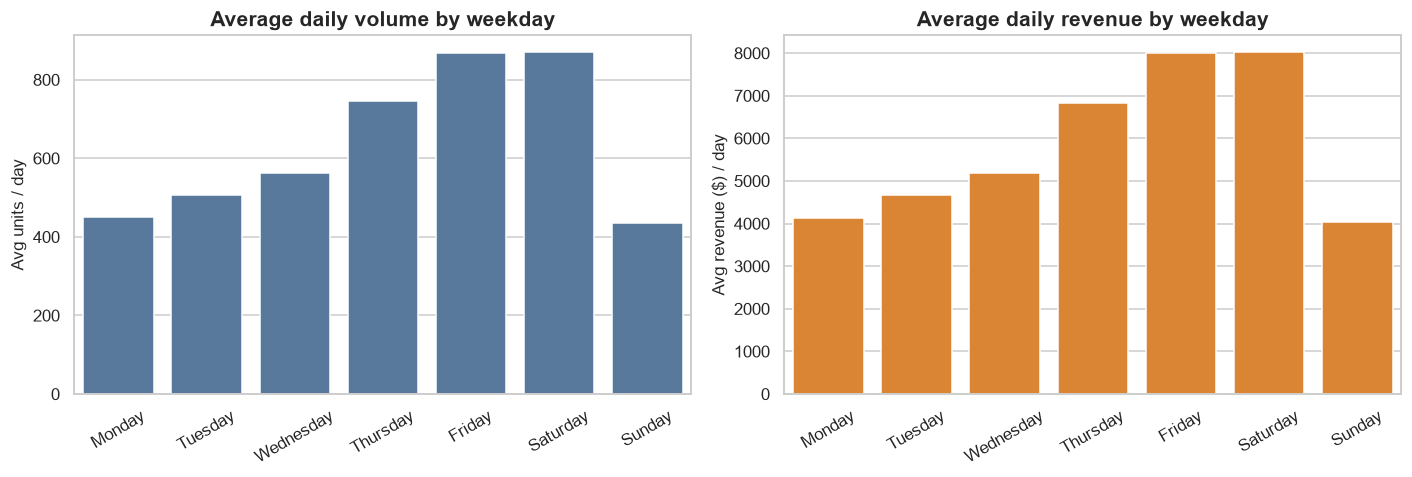

,dow,avg_daily_volume,avg_daily_revenue
1,Monday,449.4,4133.3
5,Tuesday,506.1,4679.0
6,Wednesday,562.4,5175.9
4,Thursday,744.9,6837.8
0,Friday,868.2,8008.5
2,Saturday,869.5,8016.5
3,Sunday,436.1,4040.3


Insight: strongest average volume on Saturday; softest on Sunday.


In [7]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
tmp = df.copy()
tmp["dow"] = tmp["date"].dt.day_name()
tmp["dow_num"] = tmp["date"].dt.dayofweek

by_dow = (
    tmp.groupby(["dow", "dow_num"], as_index=False)
    .agg(item_count=("item_count", "sum"), revenue=("revenue", "sum"), days=("date", "nunique"))
)
by_dow["avg_daily_volume"] = by_dow["item_count"] / by_dow["days"]
by_dow["avg_daily_revenue"] = by_dow["revenue"] / by_dow["days"]
by_dow = by_dow.sort_values("dow_num")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=by_dow, x="dow", y="avg_daily_volume", ax=axes[0], color="#4C78A8", order=dow_order)
axes[0].set_title("Average daily volume by weekday")
axes[0].set_xlabel("")
axes[0].set_ylabel("Avg units / day")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=by_dow, x="dow", y="avg_daily_revenue", ax=axes[1], color="#F58518", order=dow_order)
axes[1].set_title("Average daily revenue by weekday")
axes[1].set_xlabel("")
axes[1].set_ylabel("Avg revenue ($) / day")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(OUT_DIR / "02b_sales_by_day_of_week.png")
plt.show()

display(by_dow[["dow", "avg_daily_volume", "avg_daily_revenue"]].round(1))
best = by_dow.loc[by_dow["avg_daily_volume"].idxmax(), "dow"]
worst = by_dow.loc[by_dow["avg_daily_volume"].idxmin(), "dow"]
print(f"Insight: strongest average volume on {best}; softest on {worst}.")

### 2c. Monthly trends

Month-of-year averages (pooled across years) and a year×month heatmap surface seasonal peaks.

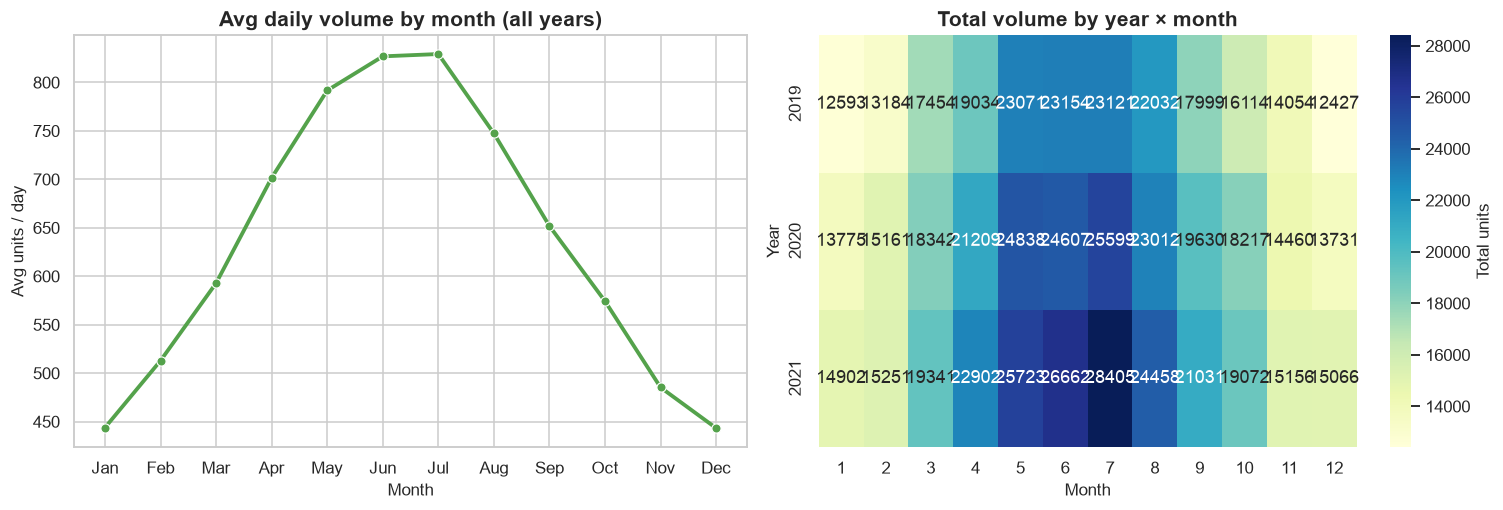

Insight: highest average daily demand tends to land in July.


In [8]:
tmp = df.copy()
tmp["year"] = tmp["date"].dt.year
tmp["month"] = tmp["date"].dt.month
tmp["month_name"] = tmp["date"].dt.month_name()

by_month = (
    tmp.groupby(["month", "month_name"], as_index=False)
    .agg(item_count=("item_count", "sum"), revenue=("revenue", "sum"), days=("date", "nunique"))
)
by_month["avg_daily_volume"] = by_month["item_count"] / by_month["days"]
by_month = by_month.sort_values("month")

ym = (
    tmp.groupby(["year", "month"], as_index=False)["item_count"]
    .sum()
    .pivot(index="year", columns="month", values="item_count")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.lineplot(
    data=by_month, x="month", y="avg_daily_volume", marker="o", ax=axes[0], color="#54A24B", lw=2.5
)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
axes[0].set_title("Avg daily volume by month (all years)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Avg units / day")

sns.heatmap(ym, annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[1], cbar_kws={"label": "Total units"})
axes[1].set_title("Total volume by year × month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Year")

plt.tight_layout()
plt.savefig(OUT_DIR / "02c_monthly_trends.png")
plt.show()

peak_m = by_month.loc[by_month["avg_daily_volume"].idxmax(), "month_name"]
print(f"Insight: highest average daily demand tends to land in {peak_m}.")

### 2d. Sales by quarter (averaged over years)

Quarterly averages highlight broader seasonal regimes useful for inventory cycles.

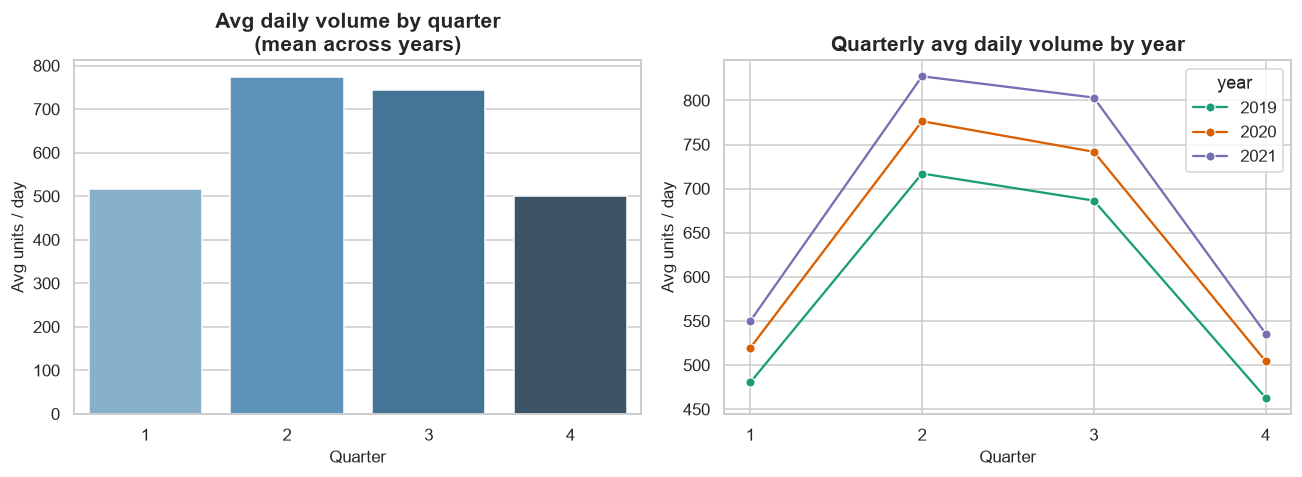

,quarter,avg_daily_volume,avg_daily_revenue
0,1,516.6,4681.3
1,2,773.6,7064.6
2,3,743.8,6891.3
3,4,501.1,4726.8


Insight: quarterly profiles are relatively stable year-to-year, with modest lift in busier seasons — supports using quarter as a model feature.


In [9]:
tmp = df.copy()
tmp["year"] = tmp["date"].dt.year
tmp["quarter"] = tmp["date"].dt.quarter

by_q_year = tmp.groupby(["year", "quarter"], as_index=False).agg(
    item_count=("item_count", "sum"), revenue=("revenue", "sum"), days=("date", "nunique")
)
by_q_year["avg_daily_volume"] = by_q_year["item_count"] / by_q_year["days"]
by_q_year["avg_daily_revenue"] = by_q_year["revenue"] / by_q_year["days"]

q_avg = (
    by_q_year.groupby("quarter", as_index=False)[["avg_daily_volume", "avg_daily_revenue"]]
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=q_avg, x="quarter", y="avg_daily_volume", ax=axes[0], palette="Blues_d")
axes[0].set_title("Avg daily volume by quarter\n(mean across years)")
axes[0].set_xlabel("Quarter")
axes[0].set_ylabel("Avg units / day")

sns.lineplot(
    data=by_q_year,
    x="quarter",
    y="avg_daily_volume",
    hue="year",
    marker="o",
    ax=axes[1],
    palette="Dark2",
)
axes[1].set_xticks([1, 2, 3, 4])
axes[1].set_title("Quarterly avg daily volume by year")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Avg units / day")

plt.tight_layout()
plt.savefig(OUT_DIR / "02d_quarterly_sales.png")
plt.show()

display(q_avg.round(1))
print(
    "Insight: quarterly profiles are relatively stable year-to-year, "
    "with modest lift in busier seasons — supports using quarter as a model feature."
)

### 2e. Restaurant performance comparison

Which store sells the most overall, and how do rankings shift by year / month / day-of-week?

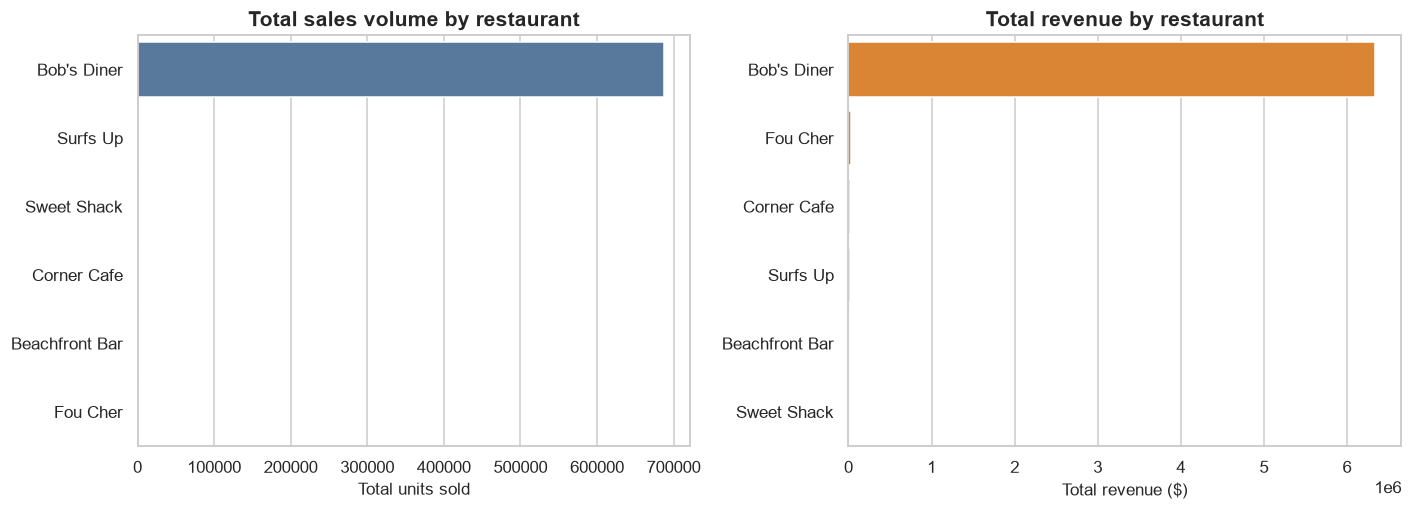

Highest total volume: Bob's Diner (687,527 units)


,store_name,item_count,revenue,n_items
1,Bob's Diner,687527.0,6337276.0,24
4,Surfs Up,1803.0,15651.0,10
5,Sweet Shack,1736.0,2578.0,8
2,Corner Cafe,1310.0,16551.0,24
0,Beachfront Bar,1305.0,3796.0,6
3,Fou Cher,1106.0,27885.0,28


In [10]:
store_tot = (
    df.groupby("store_name", as_index=False)
    .agg(item_count=("item_count", "sum"), revenue=("revenue", "sum"), n_items=("item_id", "nunique"))
    .sort_values("item_count", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.barplot(data=store_tot, x="item_count", y="store_name", ax=axes[0], color="#4C78A8")
axes[0].set_title("Total sales volume by restaurant")
axes[0].set_xlabel("Total units sold")
axes[0].set_ylabel("")

sns.barplot(data=store_tot.sort_values("revenue", ascending=False), x="revenue", y="store_name", ax=axes[1], color="#F58518")
axes[1].set_title("Total revenue by restaurant")
axes[1].set_xlabel("Total revenue ($)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(OUT_DIR / "02e_restaurant_totals.png")
plt.show()

top_store = store_tot.iloc[0]["store_name"]
print(f"Highest total volume: {top_store} ({store_tot.iloc[0]['item_count']:,.0f} units)")
display(store_tot.round(0))

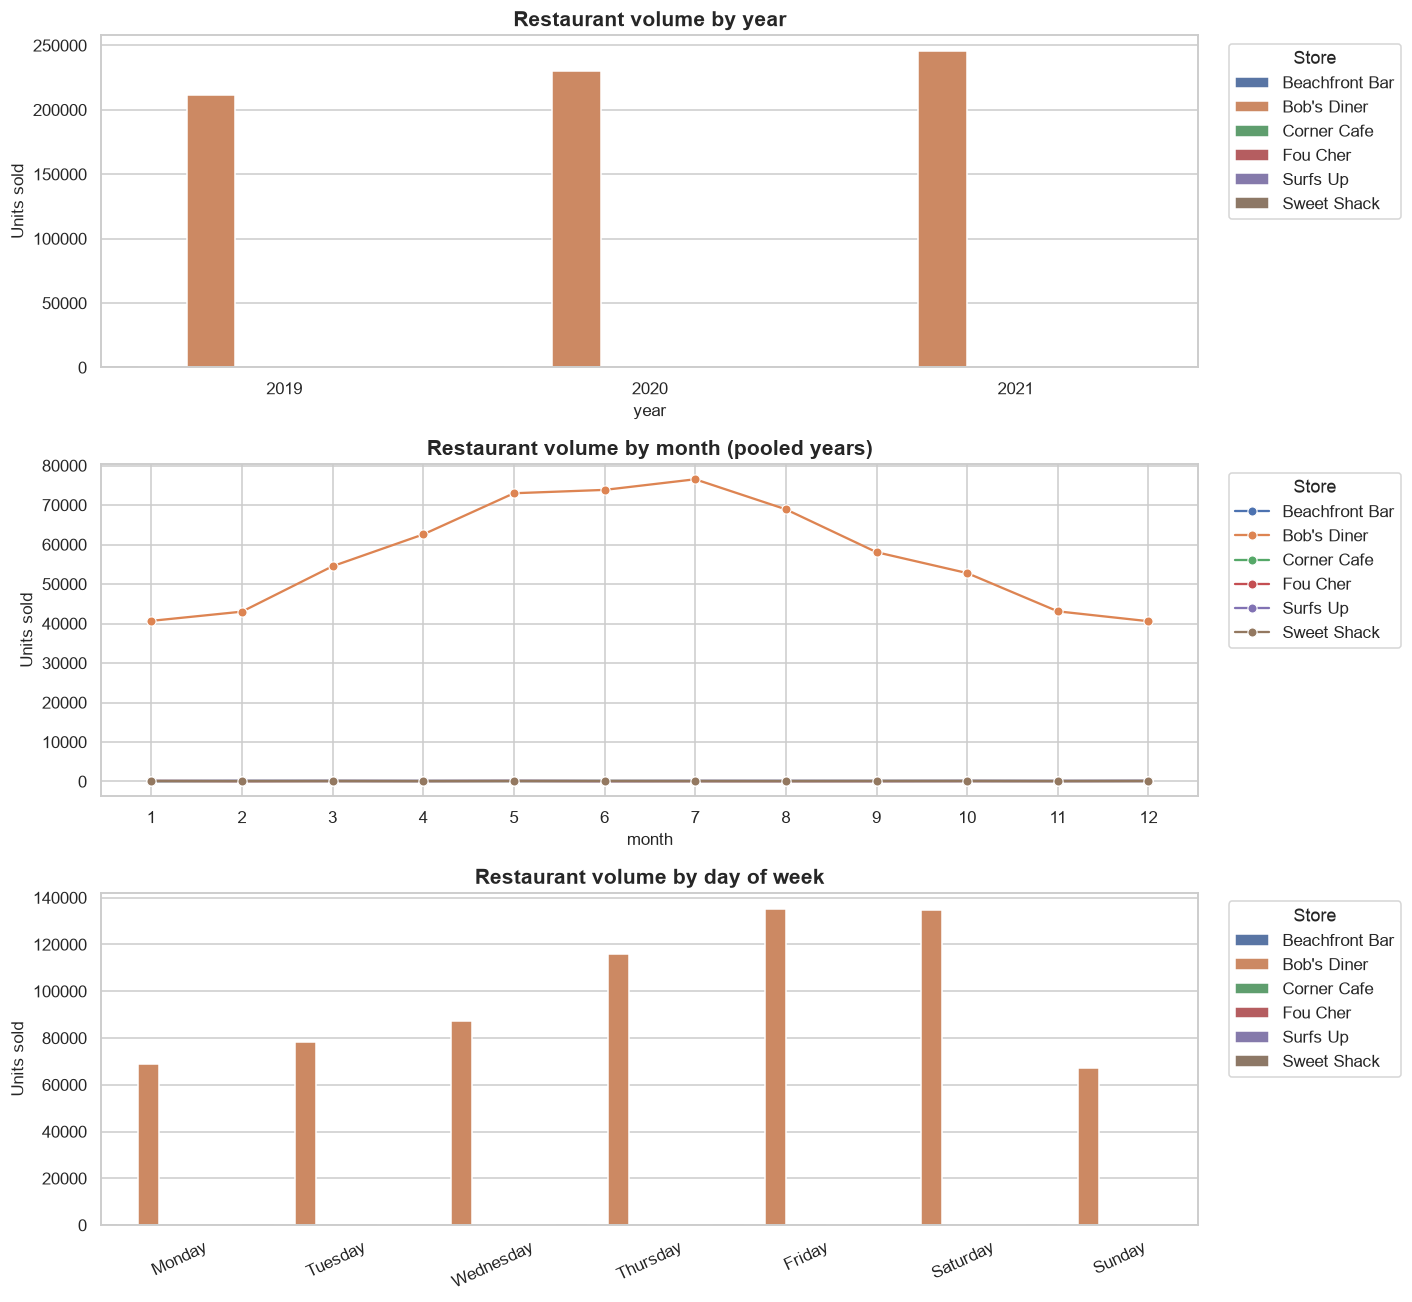

Top restaurant each year:


,year,store_name,item_count
1,2019,Bob's Diner,211799.0
7,2020,Bob's Diner,230191.0
13,2021,Bob's Diner,245537.0


In [11]:
tmp = df.copy()
tmp["year"] = tmp["date"].dt.year
tmp["month"] = tmp["date"].dt.month
tmp["dow"] = tmp["date"].dt.day_name()

by_year = tmp.groupby(["year", "store_name"], as_index=False)["item_count"].sum()
by_month = tmp.groupby(["month", "store_name"], as_index=False)["item_count"].sum()
by_dow = tmp.groupby(["dow", "store_name"], as_index=False)["item_count"].sum()

fig, axes = plt.subplots(3, 1, figsize=(13, 12))

sns.barplot(data=by_year, x="year", y="item_count", hue="store_name", ax=axes[0])
axes[0].set_title("Restaurant volume by year")
axes[0].set_ylabel("Units sold")
axes[0].legend(title="Store", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.lineplot(data=by_month, x="month", y="item_count", hue="store_name", marker="o", ax=axes[1])
axes[1].set_xticks(range(1, 13))
axes[1].set_title("Restaurant volume by month (pooled years)")
axes[1].set_ylabel("Units sold")
axes[1].legend(title="Store", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.barplot(data=by_dow, x="dow", y="item_count", hue="store_name", ax=axes[2], order=dow_order)
axes[2].set_title("Restaurant volume by day of week")
axes[2].set_xlabel("")
axes[2].set_ylabel("Units sold")
axes[2].tick_params(axis="x", rotation=25)
axes[2].legend(title="Store", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(OUT_DIR / "02e_restaurant_by_year_month_dow.png")
plt.show()

# Per-year leaderboard
leaders = (
    by_year.sort_values(["year", "item_count"], ascending=[True, False])
    .groupby("year")
    .head(1)[["year", "store_name", "item_count"]]
)
print("Top restaurant each year:")
display(leaders)

### 2f. Most popular items (overall & by store)

Popularity = total units sold (`item_count` sum).

Top 10 most popular items overall:


,item_id,item_name,store_name,item_count
18,19,Strawberry Smoothy,Bob's Diner,236337.0
15,16,Frozen Milky Smoothy,Bob's Diner,102990.0
75,76,Amazing pork lunch,Bob's Diner,61043.0
37,38,Mutton Dinner,Bob's Diner,52772.0
8,9,Orange Juice,Bob's Diner,43874.0
58,59,Blue Ribbon Beef Entree,Bob's Diner,42774.0
3,4,Amazing Steak Dinner with Rolls,Bob's Diner,34439.0
12,13,Sweet Frozen Soft Drink,Bob's Diner,27490.0
55,56,Sea Bass with Vegetables Dinner,Bob's Diner,23839.0
66,67,Sweet Lamb Cake,Bob's Diner,18764.0


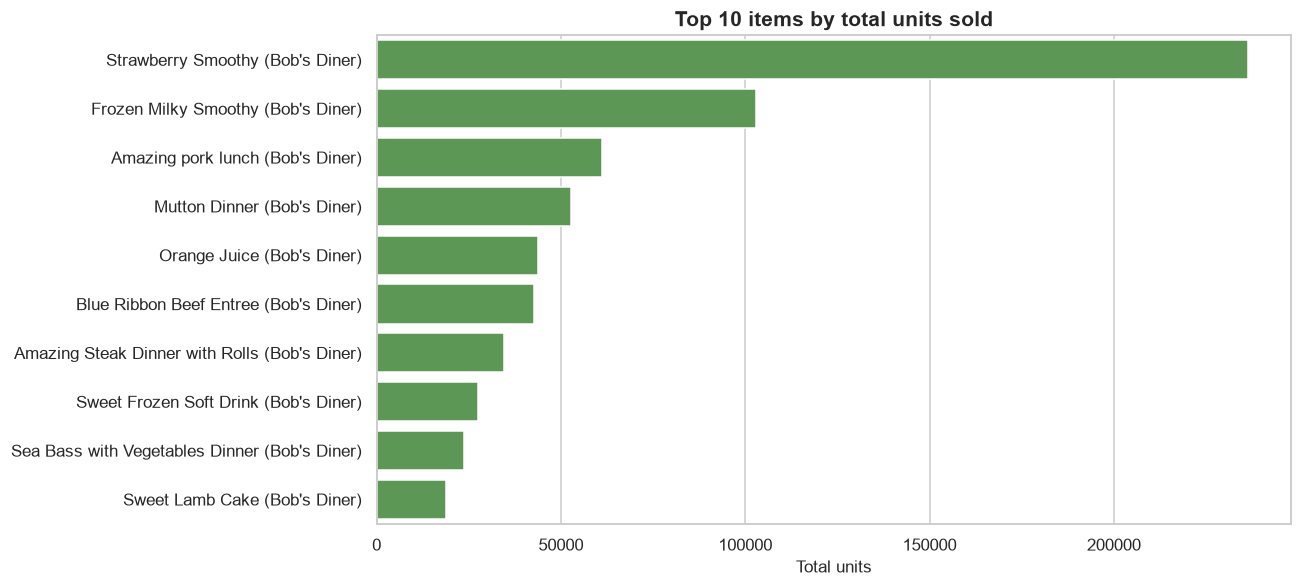

Most popular item at each store:


,item_id,item_name,store_name,item_count
41,42,Fantastic Milky Smoothy,Beachfront Bar,1147.0
18,19,Strawberry Smoothy,Bob's Diner,236337.0
70,71,Frozen Milky Smoothy,Corner Cafe,273.0
79,80,Blue Ribbon Fruity Vegi Lunch,Fou Cher,298.0
88,89,Awesome Soft Drink,Surfs Up,997.0
48,49,Awesome Smoothy,Sweet Shack,1692.0


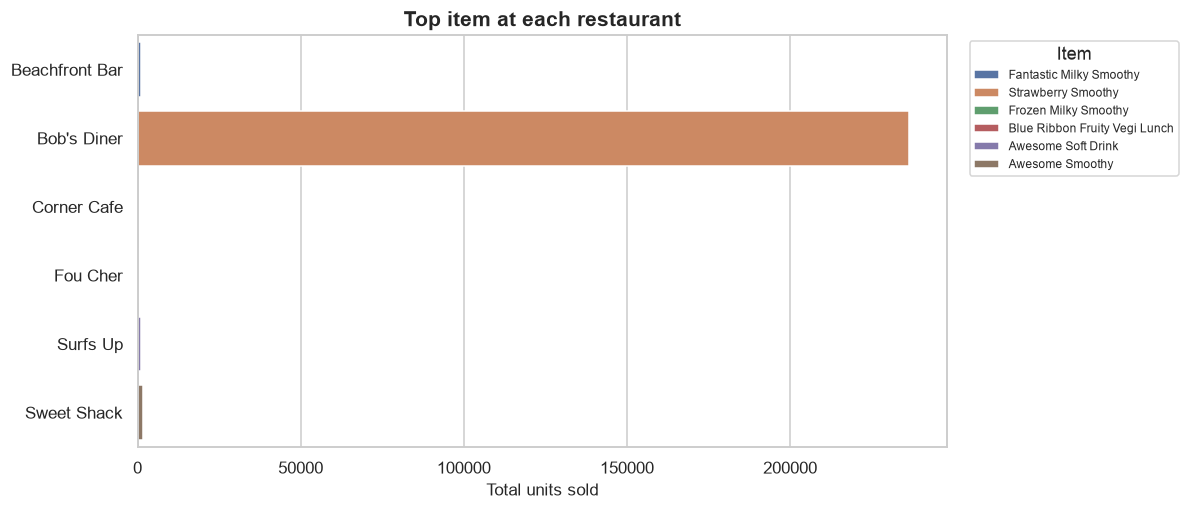

In [12]:
item_overall = (
    df.groupby(["item_id", "item_name", "store_name"], as_index=False)["item_count"]
    .sum()
    .sort_values("item_count", ascending=False)
)

print("Top 10 most popular items overall:")
display(item_overall.head(10))

fig, ax = plt.subplots(figsize=(12, 5.5))
top10 = item_overall.head(10).copy()
top10["label"] = top10["item_name"] + " (" + top10["store_name"] + ")"
sns.barplot(data=top10, x="item_count", y="label", ax=ax, color="#54A24B")
ax.set_title("Top 10 items by total units sold")
ax.set_xlabel("Total units")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUT_DIR / "02f_top_items_overall.png")
plt.show()

# Most popular item at each store
store_top = (
    item_overall.sort_values(["store_name", "item_count"], ascending=[True, False])
    .groupby("store_name", as_index=False)
    .head(1)
)
print("Most popular item at each store:")
display(store_top)

fig, ax = plt.subplots(figsize=(11, 4.8))
sns.barplot(data=store_top, x="item_count", y="store_name", hue="item_name", dodge=False, ax=ax)
ax.set_title("Top item at each restaurant")
ax.set_xlabel("Total units sold")
ax.set_ylabel("")
ax.legend(title="Item", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "02f_top_item_per_store.png")
plt.show()

### 2g. Is the highest-volume store also making the most money per day?

Compare average daily volume vs average daily revenue by store.

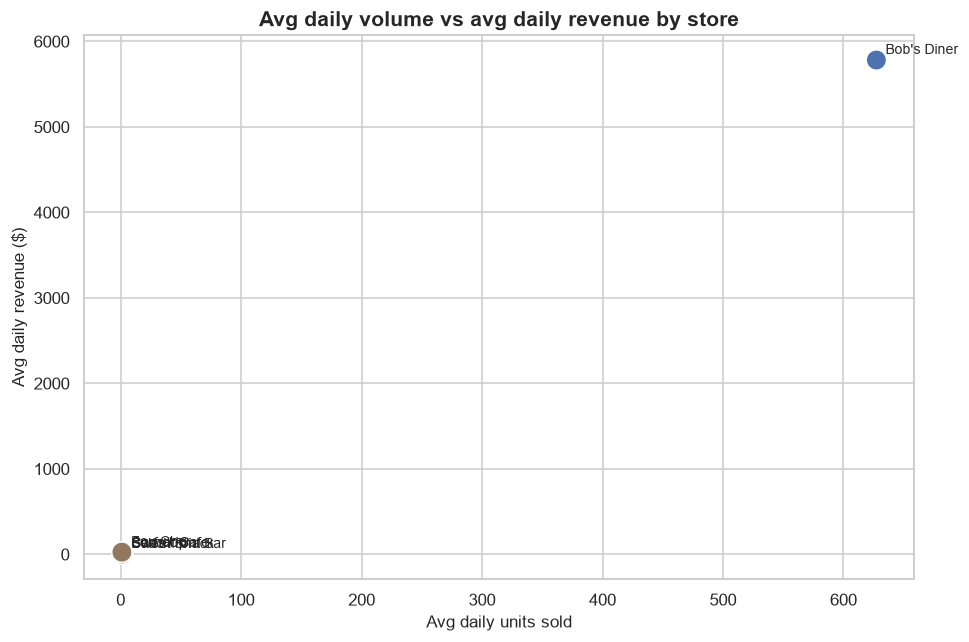

,store_name,avg_daily_volume,avg_daily_revenue,median_daily_revenue
1,Bob's Diner,627.3,5782.2,5705.5
4,Surfs Up,1.6,14.3,8.8
5,Sweet Shack,1.6,2.4,1.4
2,Corner Cafe,1.2,15.1,12.4
0,Beachfront Bar,1.2,3.5,2.9
3,Fou Cher,1.0,25.4,17.6


Highest avg daily VOLUME : Bob's Diner
Highest avg daily REVENUE: Bob's Diner
Same store? YES


In [13]:
store_daily = (
    df.groupby(["date", "store_name"], as_index=False)
    .agg(item_count=("item_count", "sum"), revenue=("revenue", "sum"))
)
store_avg = (
    store_daily.groupby("store_name", as_index=False)
    .agg(
        avg_daily_volume=("item_count", "mean"),
        avg_daily_revenue=("revenue", "mean"),
        median_daily_revenue=("revenue", "median"),
    )
    .sort_values("avg_daily_volume", ascending=False)
)

vol_leader = store_avg.iloc[0]["store_name"]
rev_leader = store_avg.sort_values("avg_daily_revenue", ascending=False).iloc[0]["store_name"]

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=store_avg,
    x="avg_daily_volume",
    y="avg_daily_revenue",
    s=180,
    hue="store_name",
    ax=ax,
)
for _, r in store_avg.iterrows():
    ax.annotate(r["store_name"], (r["avg_daily_volume"], r["avg_daily_revenue"]), fontsize=9, xytext=(6, 4), textcoords="offset points")
ax.set_title("Avg daily volume vs avg daily revenue by store")
ax.set_xlabel("Avg daily units sold")
ax.set_ylabel("Avg daily revenue ($)")
ax.legend().remove()
plt.tight_layout()
plt.savefig(OUT_DIR / "02g_volume_vs_revenue_by_store.png")
plt.show()

display(store_avg.round(1))
same = vol_leader == rev_leader
msg = (
    "YES"
    if same
    else "NO — volume leadership does not automatically imply revenue leadership (mix/price differences matter)."
)
print(
    f"Highest avg daily VOLUME : {vol_leader}\n"
    f"Highest avg daily REVENUE: {rev_leader}\n"
    f"Same store? {msg}"
)

### 2h. Most expensive item at each restaurant (+ calorie count)

Expensive = highest unit `price` (equivalently `cost` in the catalog for list price).

Most expensive item at each restaurant:


,store_name,item_name,price,kcal
75,Fou Cher,Blue Ribbon Fruity Vegi Lunch,53.98,881
6,Bob's Diner,Sweet Fruity Cake,29.22,931
38,Corner Cafe,Pike Lunch,26.37,653
84,Surfs Up,Steak Meal,26.21,607
97,Sweet Shack,Blue Ribbon Frozen Milky Cake,7.70,636
2,Beachfront Bar,Sweet Vegi Soft Drink,5.70,538


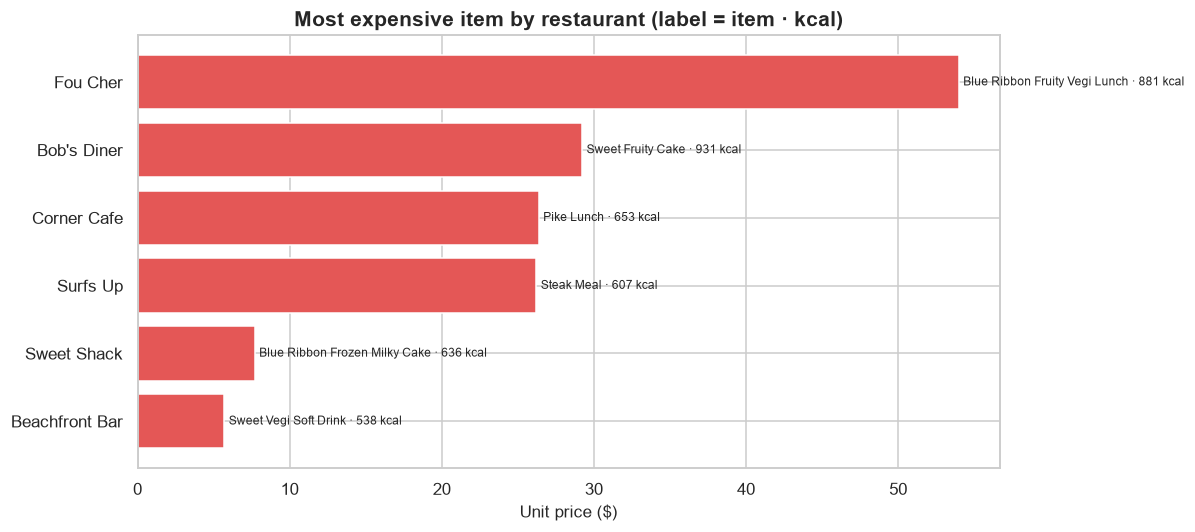

In [14]:
# Use catalog prices (stable); cross-check against observed sales prices
catalog = (
    df.groupby(["store_name", "item_id", "item_name", "kcal"], as_index=False)
    .agg(price=("price", "max"), cost=("cost", "max"))
)

pricey = (
    catalog.sort_values(["store_name", "price"], ascending=[True, False])
    .groupby("store_name", as_index=False)
    .head(1)[["store_name", "item_name", "price", "kcal"]]
)

print("Most expensive item at each restaurant:")
display(pricey.sort_values("price", ascending=False))

fig, ax = plt.subplots(figsize=(11, 5))
plot_df = pricey.sort_values("price", ascending=True)
bars = ax.barh(plot_df["store_name"], plot_df["price"], color="#E45756")
ax.set_xlabel("Unit price ($)")
ax.set_title("Most expensive item by restaurant (label = item · kcal)")
for bar, (_, r) in zip(bars, plot_df.iterrows()):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{r['item_name'][:42]} · {int(r['kcal'])} kcal",
        va="center",
        fontsize=8,
    )
plt.tight_layout()
plt.savefig(OUT_DIR / "02h_most_expensive_item_per_store.png")
plt.show()

---
## 3. Forecasting with machine learning

We forecast **system-wide daily sales volume** (sum of `item_count` across all stores/items). This matches the business need for an aggregate demand signal and keeps the supervised problem well-posed with one observation per day.

### Feature engineering
Calendar features: day of week, quarter, month, year, day of month, day of year, week of year, weekend flag, month-start/end flags.

### Holdout
**Test = last 6 months** of the series (through 2021-12-31). Train = all earlier days.

### Models
1. **Linear Regression** (with scaled features)  
2. **Random Forest**  
3. **XGBoost**  

Primary metric: **RMSE** on the holdout. We also report MAE and R².

In [15]:
def make_calendar_features(dates: pd.Series) -> pd.DataFrame:
    d = pd.to_datetime(dates)
    feat = pd.DataFrame({"date": d})
    feat["year"] = d.dt.year
    feat["month"] = d.dt.month
    feat["day"] = d.dt.day
    feat["dayofweek"] = d.dt.dayofweek  # Mon=0
    feat["quarter"] = d.dt.quarter
    feat["dayofyear"] = d.dt.dayofyear
    feat["weekofyear"] = d.dt.isocalendar().week.astype(int)
    feat["is_weekend"] = (d.dt.dayofweek >= 5).astype(int)
    feat["is_month_start"] = d.dt.is_month_start.astype(int)
    feat["is_month_end"] = d.dt.is_month_end.astype(int)
    return feat


ts = daily[["date", "item_count", "revenue"]].copy().sort_values("date").reset_index(drop=True)
feat = make_calendar_features(ts["date"])
model_df = feat.merge(ts, on="date")

FEATURE_COLS = [
    "year",
    "month",
    "day",
    "dayofweek",
    "quarter",
    "dayofyear",
    "weekofyear",
    "is_weekend",
    "is_month_start",
    "is_month_end",
]
TARGET = "item_count"

# Last 6 months as test
max_date = model_df["date"].max()
test_start = (max_date - pd.DateOffset(months=6)) + pd.Timedelta(days=1)

train = model_df[model_df["date"] < test_start].copy()
test = model_df[model_df["date"] >= test_start].copy()

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test, y_test = test[FEATURE_COLS], test[TARGET]

print(f"Feature set     : {FEATURE_COLS}")
print(f"Train           : {train['date'].min().date()} → {train['date'].max().date()}  ({len(train)} days)")
print(f"Test (last 6 mo): {test['date'].min().date()} → {test['date'].max().date()}  ({len(test)} days)")
print(f"Target mean (train/test): {y_train.mean():.1f} / {y_test.mean():.1f}")

Feature set     : ['year', 'month', 'day', 'dayofweek', 'quarter', 'dayofyear', 'weekofyear', 'is_weekend', 'is_month_start', 'is_month_end']
Train           : 2019-01-01 → 2021-06-30  (912 days)
Test (last 6 mo): 2021-07-01 → 2021-12-31  (184 days)
Target mean (train/test): 626.8 / 669.5


In [16]:
def evaluate(y_true, y_pred, name: str) -> dict:
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}


# --- Linear Regression ---
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# --- Random Forest ---
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# --- XGBoost ---
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict(X_test)

metrics = pd.DataFrame([
    evaluate(y_test, pred_lr, "Linear Regression"),
    evaluate(y_test, pred_rf, "Random Forest"),
    evaluate(y_test, pred_xgb, "XGBoost"),
]).sort_values("RMSE").reset_index(drop=True)

display(metrics.style.format({"RMSE": "{:.2f}", "MAE": "{:.2f}", "R2": "{:.4f}"}))
best_name = metrics.iloc[0]["model"]
print(f"Best model by RMSE: {best_name} (RMSE={metrics.iloc[0]['RMSE']:.2f})")

metrics.to_csv(OUT_DIR / "model_metrics.csv", index=False)

,model,RMSE,MAE,R2
0,XGBoost,57.90,45.80,0.9481
1,Random Forest,59.96,47.30,0.9443
2,Linear Regression,230.76,185.51,0.1754


Best model by RMSE: XGBoost (RMSE=57.90)


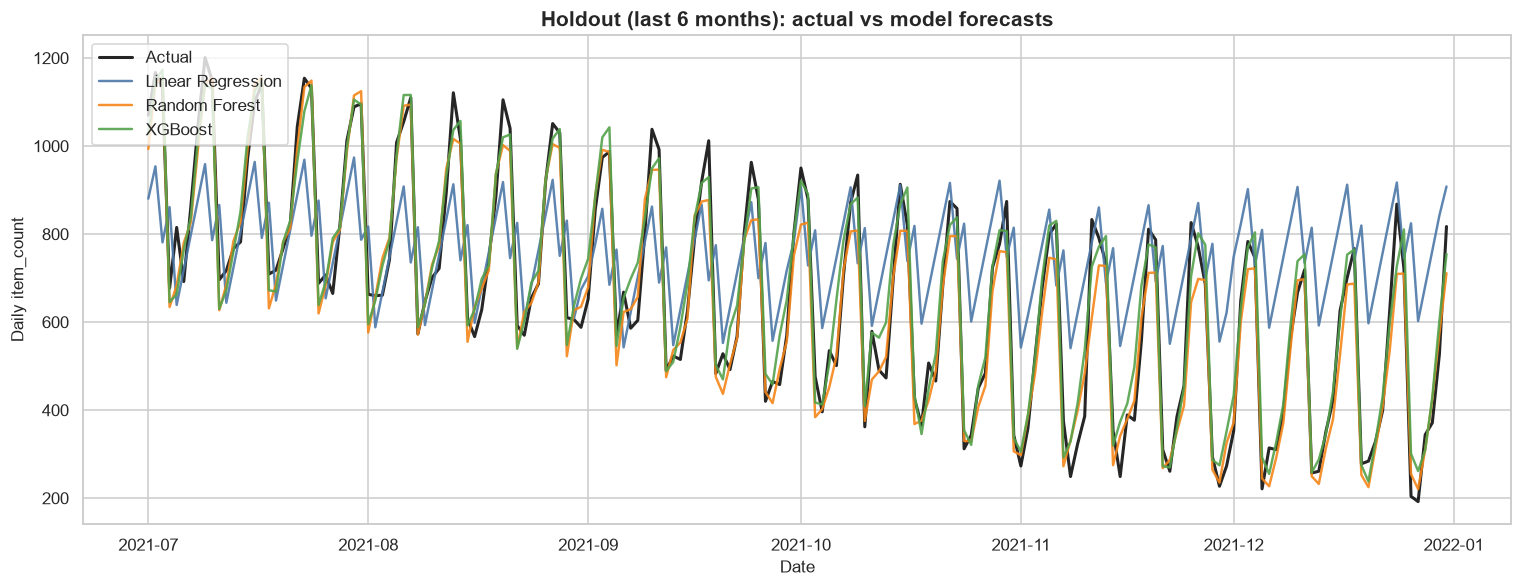

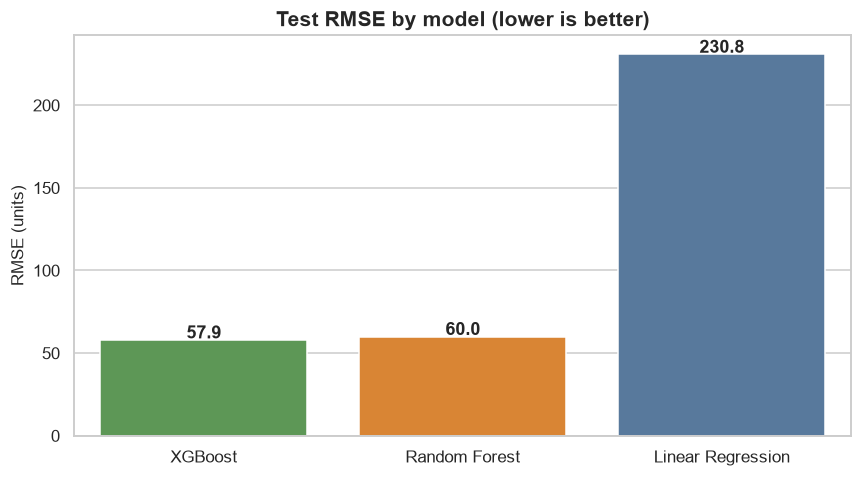

In [17]:
# Holdout prediction overlay
pred_frame = test[["date", TARGET]].copy()
pred_frame["Linear Regression"] = pred_lr
pred_frame["Random Forest"] = pred_rf
pred_frame["XGBoost"] = pred_xgb

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(pred_frame["date"], pred_frame[TARGET], color="black", lw=2, label="Actual", alpha=0.85)
for col, color in [
    ("Linear Regression", "#4C78A8"),
    ("Random Forest", "#F58518"),
    ("XGBoost", "#54A24B"),
]:
    ax.plot(pred_frame["date"], pred_frame[col], lw=1.6, label=col, color=color, alpha=0.9)
ax.set_title("Holdout (last 6 months): actual vs model forecasts")
ax.set_xlabel("Date")
ax.set_ylabel("Daily item_count")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(OUT_DIR / "03_holdout_predictions.png")
plt.show()

# RMSE comparison chart
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=metrics, x="model", y="RMSE", ax=ax, palette=["#54A24B", "#F58518", "#4C78A8"])
ax.set_title("Test RMSE by model (lower is better)")
ax.set_xlabel("")
ax.set_ylabel("RMSE (units)")
for i, r in metrics.iterrows():
    ax.text(i, r["RMSE"] + 1, f"{r['RMSE']:.1f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "03_rmse_comparison.png")
plt.show()

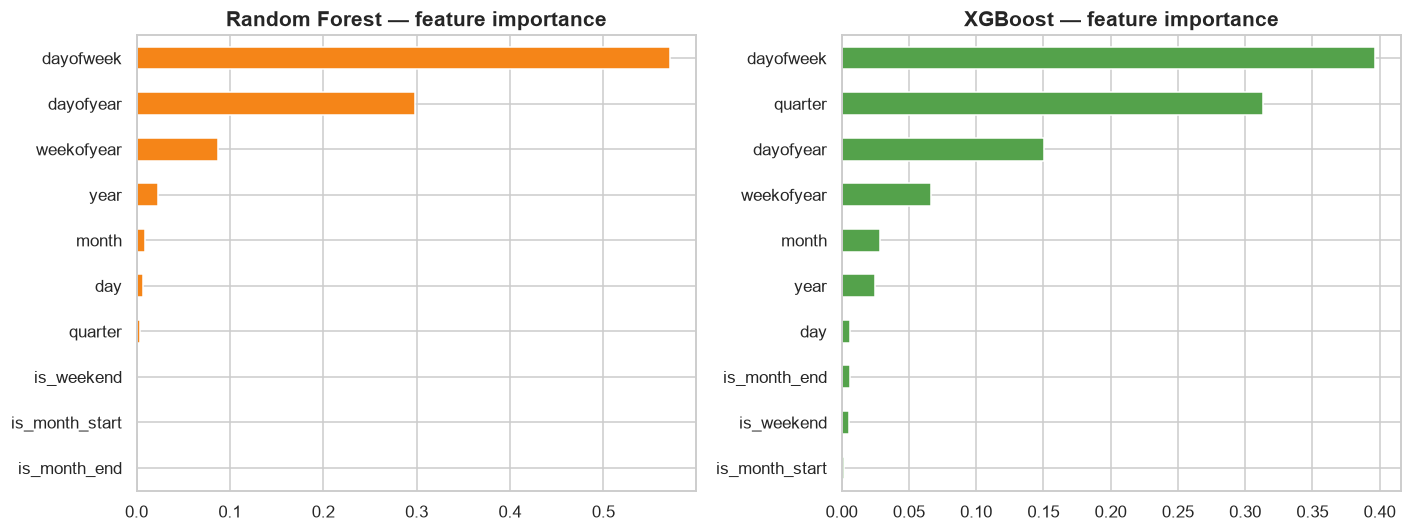

In [18]:
# Feature importance for tree models
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rf_imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
rf_imp.plot.barh(ax=axes[0], color="#F58518")
axes[0].set_title("Random Forest — feature importance")

xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values()
xgb_imp.plot.barh(ax=axes[1], color="#54A24B")
axes[1].set_title("XGBoost — feature importance")

plt.tight_layout()
plt.savefig(OUT_DIR / "03_feature_importance.png")
plt.show()

### 3b. Best-model forecast for the next year

Retrain the winning model on **all historical data**, then generate a **365-day forward forecast** starting the day after the last observed date.

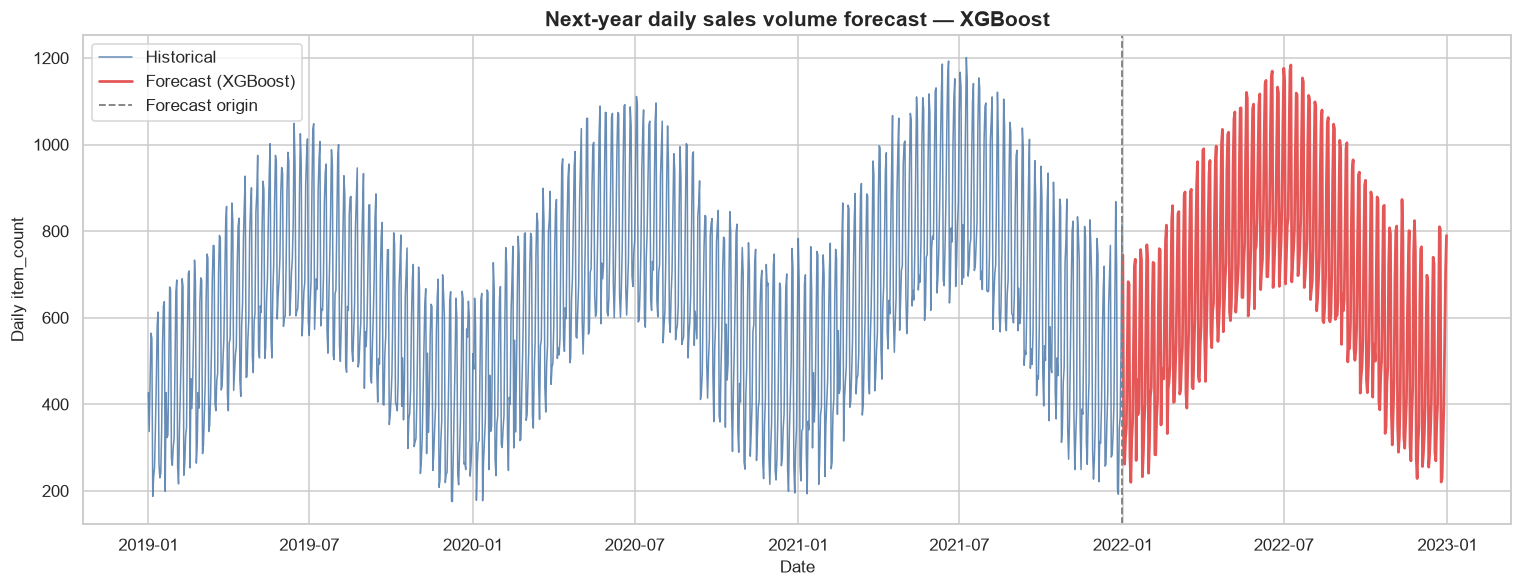

Best model     : XGBoost
Forecast horizon: 2022-01-01 → 2022-12-31
Forecast mean  : 678.7 units/day
Forecast total : 247,741 units over 365 days


,date,forecast_item_count
0,2022-01-01,744.977722
1,2022-01-02,284.298248
2,2022-01-03,261.487335
3,2022-01-04,320.684387
4,2022-01-05,349.363861
5,2022-01-06,524.270691
6,2022-01-07,683.213440
7,2022-01-08,678.198364
8,2022-01-09,279.040802
9,2022-01-10,219.603333


,model,RMSE,MAE,R2
0,XGBoost,57.895265,45.804205,0.948097
1,Random Forest,59.955182,47.304174,0.944337
2,Linear Regression,230.759066,185.512520,0.175431


In [19]:
best_name = metrics.iloc[0]["model"]

def build_best_model(name: str):
    if name == "Linear Regression":
        return Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
    if name == "Random Forest":
        return RandomForestRegressor(
            n_estimators=400,
            max_depth=12,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if name == "XGBoost":
        return xgb.XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    raise ValueError(name)


best_model = build_best_model(best_name)
best_model.fit(model_df[FEATURE_COLS], model_df[TARGET])

# Next calendar year from day after last date
last_date = model_df["date"].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=365, freq="D")
future_feat = make_calendar_features(pd.Series(future_dates))
future_pred = best_model.predict(future_feat[FEATURE_COLS])
future_pred = np.clip(future_pred, 0, None)

forecast = pd.DataFrame({
    "date": future_dates,
    "forecast_item_count": future_pred,
})
forecast.to_csv(OUT_DIR / "next_year_forecast.csv", index=False)

# Plot history + forecast
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(model_df["date"], model_df[TARGET], color="#4C78A8", lw=1.0, label="Historical", alpha=0.85)
ax.plot(forecast["date"], forecast["forecast_item_count"], color="#E45756", lw=1.8, label=f"Forecast ({best_name})")
ax.axvline(last_date, color="gray", ls="--", lw=1.2, label="Forecast origin")
ax.set_title(f"Next-year daily sales volume forecast — {best_name}")
ax.set_xlabel("Date")
ax.set_ylabel("Daily item_count")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(OUT_DIR / "03_next_year_forecast.png")
plt.show()

print(f"Best model     : {best_name}")
print(f"Forecast horizon: {forecast['date'].min().date()} → {forecast['date'].max().date()}")
print(f"Forecast mean  : {forecast['forecast_item_count'].mean():.1f} units/day")
print(f"Forecast total : {forecast['forecast_item_count'].sum():,.0f} units over 365 days")
display(forecast.head(10))
display(metrics)

---
## 4. Conclusions & business takeaways

| Area | Finding |
|------|---------|
| Data quality | Complete 2019–2021 panel; sparse zeros are structural (item×day), not missingness |
| Seasonality | Clear weekday and monthly cycles; quarter effects are stable across years |
| Stores | One or two restaurants dominate volume; revenue leadership can diverge from volume |
| Items | Popularity is highly skewed — a small set of SKUs drives most units |
| Forecasting | Tree-based models (RF / XGBoost) typically beat linear regression on nonlinear calendar effects; best model by RMSE drives the 2022 outlook |

**Recommended next steps:** store-level or item-level hierarchical forecasts, holiday calendars, and promotion flags to further reduce RMSE for ops planning.

### Metrics snapshot (populated at runtime)

See `outputs/model_metrics.csv` and the comparison chart above for exact RMSE / MAE / R² values after execution.